In [12]:
# ============================================================
# V2 phase separation heat map from sweep CSV
# ============================================================

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

import md_Helpers.Sweep_Helpers as sw

importlib.reload(sw)


# ============================================================
# Sweep settings
# Must match the sweep CSV you made
# ============================================================

n_fcc_cells = 30

rho_min  = 0.700
rho_max  = 0.720
rho_step = 0.001

kT_min = 0.80
kT_max = 0.80
kT_step = 0.02

nsteps = 1_000_000


# ============================================================
# Rebuild expected sweep grid
# ============================================================

rho_values = sw.make_scan_values(
    rho_min,
    rho_max,
    rho_step,
)

kT_values = sw.make_scan_values(
    kT_min,
    kT_max,
    kT_step,
)


# ============================================================
# CSV path
# ============================================================

summary_path = sw.get_v2_summary_path(
    n_fcc_cells=n_fcc_cells,
    kT_min=kT_min,
    kT_max=kT_max,
    rho_min=rho_min,
    rho_max=rho_max,
    nsteps=nsteps,
)

df = pd.read_csv(summary_path)

print("Loaded sweep CSV:")
print(summary_path)
print("Rows in CSV:", len(df))


# ============================================================
# Clean phase_separated column
# ============================================================

df["phase_separated_clean"] = df["phase_separated"].apply(
    sw.clean_bool_value
)


# ============================================================
# Build full expected grid, including not-yet-run points
# ============================================================

full_grid = sw.build_full_grid(
    kT_values=kT_values,
    rho_values=rho_values,
)

# Keep only the most recent row for each point, in case duplicates exist
df_sorted = df.sort_values(
    [
        "kT",
        "target_rho",
    ]
).copy()

df_unique = (
    df_sorted
    .drop_duplicates(
        subset=[
            "kT",
            "target_rho",
        ],
        keep="last",
    )
    .copy()
)

plot_df = full_grid.merge(
    df_unique,
    on=[
        "kT",
        "target_rho",
    ],
    how="left",
)


# ============================================================
# Encode values for heat map
#
# -1 = missing, failed, incomplete, or no usable phase flag
#  0 = completed and phase_separated is False
#  1 = completed and phase_separated is True
# ============================================================

def encode_phase_row(row):
    if row.get("status") != "completed":
        return -1

    if row.get("phase_separated_clean") is True:
        return 1

    if row.get("phase_separated_clean") is False:
        return 0

    return -1


plot_df["phase_code"] = plot_df.apply(
    encode_phase_row,
    axis=1,
)


# ============================================================
# Pivot into heat map grid
# ============================================================

heatmap_grid = plot_df.pivot(
    index="kT",
    columns="target_rho",
    values="phase_code",
)

# Lower temperatures at the bottom of the plot
heatmap_grid = heatmap_grid.sort_index(
    ascending=True,
)


# ============================================================
# Plot heat map
# ============================================================

plt.figure(figsize=(10, 8))

# Colors:
# grey  = missing / failed / not reached yet
# blue  = phase_separated False
# red   = phase_separated True
cmap = ListedColormap(
    [
        "lightgray",
        "royalblue",
        "tomato",
    ]
)

bounds = [
    -1.5,
    -0.5,
    0.5,
    1.5,
]

norm = BoundaryNorm(
    bounds,
    cmap.N,
)

plt.imshow(
    heatmap_grid.values,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

plt.xticks(
    ticks=np.arange(len(heatmap_grid.columns)),
    labels=[f"{rho:.2f}" for rho in heatmap_grid.columns],
    rotation=45,
)

plt.yticks(
    ticks=np.arange(len(heatmap_grid.index)),
    labels=[f"{kT:.2f}" for kT in heatmap_grid.index],
)

plt.xlabel("Target density")
plt.ylabel("Temperature kT")

plt.title(
    f"Phase separation sweep\n"
    f"FCC, n_cells = {n_fcc_cells}, N = {4 * n_fcc_cells**3}, "
    f"nsteps = {nsteps:,}"
)


# ============================================================
# Add grid lines between boxes
# ============================================================

ax = plt.gca()

ax.set_xticks(
    np.arange(
        -0.5,
        len(heatmap_grid.columns),
        1,
    ),
    minor=True,
)

ax.set_yticks(
    np.arange(
        -0.5,
        len(heatmap_grid.index),
        1,
    ),
    minor=True,
)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=0.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ============================================================
# Add legend
# ============================================================

legend_handles = [
    Patch(
        facecolor="tomato",
        edgecolor="black",
        label="Phase separated = True",
    ),
    Patch(
        facecolor="royalblue",
        edgecolor="black",
        label="Phase separated = False",
    ),
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Missing / failed / not reached",
    ),
]

plt.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)

plt.tight_layout()
plt.show()


# ============================================================
# Print quick progress summary
# ============================================================

n_total = len(plot_df)
n_completed = (plot_df["status"] == "completed").sum()
n_failed = (plot_df["status"] == "failed").sum()
n_missing_or_unreached = (plot_df["phase_code"] == -1).sum()
n_phase_true = (plot_df["phase_code"] == 1).sum()
n_phase_false = (plot_df["phase_code"] == 0).sum()

print("=" * 80)
print("Sweep CSV summary")
print("=" * 80)
print("CSV file:", summary_path)
print(f"n_fcc_cells:                  {n_fcc_cells}")
print(f"N:                            {4 * n_fcc_cells**3}")
print(f"Total grid points:            {n_total}")
print(f"Completed rows:               {n_completed}")
print(f"Failed rows:                  {n_failed}")
print(f"Missing / failed / not reached: {n_missing_or_unreached}")
print(f"Phase separated True:         {n_phase_true}")
print(f"Phase separated False:        {n_phase_false}")
print("=" * 80)


# ============================================================
# Show table used for plotting
# ============================================================

plot_df.sort_values(
    [
        "kT",
        "target_rho",
    ]
)

FileNotFoundError: [Errno 2] No such file or directory: '/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Sweep_Summaries/sweep_summary_ncells_30_kT_0.80_0.80_rho_0.70_0.72_nsteps_1000000.csv'

Loaded CSV:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Adaptive_Pressure_Window_Summaries/adaptive_pressure_window_ncells_30_kT_0p700_1p000_P_0p000_0p150_drho_0p005_nsteps_1000000_seed_1.csv
Rows in CSV: 147

Completed rows before phase/adaptive filters: 147
ignore_phase_separated: True
plot_only_inside_pressure_window: False
plot_only_used_for_bracket: False
Rows kept for plotting: 146


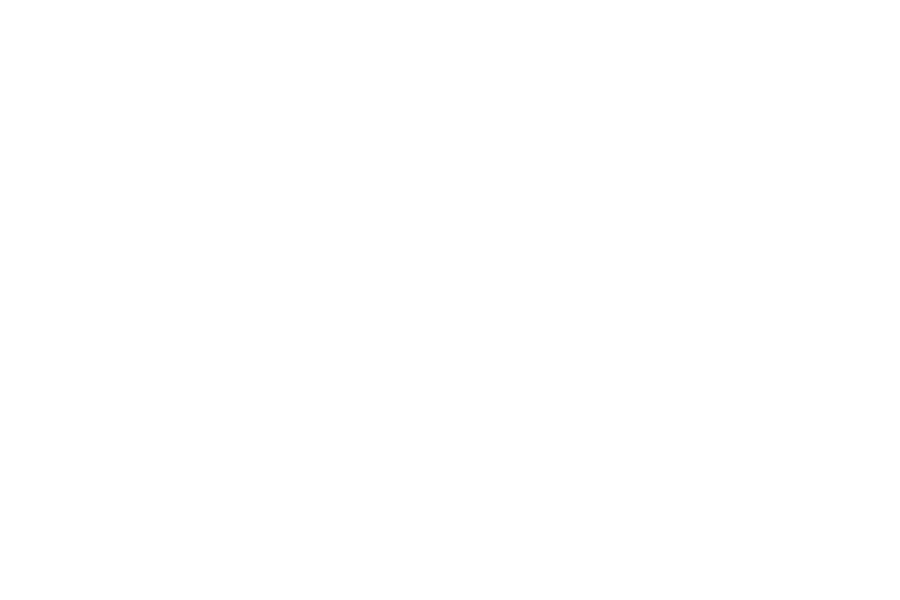

,kT,target_rho,actual_rho,N,BoxLength,pressure_mean_last100,pressure_std_last100,pressure_region,inside_pressure_window,used_for_bracket,phase_separated_clean,status
0,0.7,0.800,0.800,108000,51.299278,-0.111740,0.012039,below_lower_stop,False,False,False,completed
1,0.7,0.805,0.805,108000,51.192848,-0.057570,0.010775,below_lower_stop,False,True,False,completed
2,0.7,0.810,0.810,108000,51.087296,0.000068,0.009695,inside_pressure_window,True,True,False,completed
3,0.7,0.815,0.815,108000,50.982609,0.058018,0.011577,inside_pressure_window,True,True,False,completed
4,0.7,0.820,0.820,108000,50.878773,0.119560,0.011564,inside_pressure_window,True,True,False,completed
...,...,...,...,...,...,...,...,...,...,...,...,...
141,1.0,0.650,0.650,108000,54.975620,0.114540,0.011063,inside_pressure_window,True,True,False,completed
142,1.0,0.655,0.655,108000,54.835377,0.132486,0.011113,inside_pressure_window,True,True,False,completed
143,1.0,0.660,0.660,108000,54.696552,0.152198,0.012085,above_pressure_window,False,True,False,completed
144,1.0,0.665,0.665,108000,54.559120,0.174896,0.010102,above_pressure_window,False,True,False,completed


In [11]:
# ============================================================
# Adaptive/sliding-window CSV plot:
# pressure or PE/N or KE/N vs actual density
# One color per temperature
# ============================================================

from pathlib import Path
import importlib


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipympl

import md_Helpers.Sweep_Helpers as sw

importlib.reload(sw)


# ============================================================
# User settings
# ============================================================

# Put the adaptive/sliding-window CSV path here


#First Sweep
#summary_path = Path("/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Sweep_Summaries/sweep_summary_ncells_30_kT_0.70_1.00_rho_0.50_0.80_nsteps_1000000.csv")

#Sliding Window
summary_path = Path("/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Adaptive_Pressure_Window_Summaries/adaptive_pressure_window_ncells_30_kT_0p700_1p000_P_0p000_0p150_drho_0p005_nsteps_1000000_seed_1.csv")

#Master csv
#summary_path = Path('/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Master_Summaries/master_v2_ncells_30_randomization.csv')





# Quantity to plot
quantity_to_plot = "pressure"
# Options:
#   "pressure"
#   "PE_per_particle"
#   "KE_per_particle"
#   "kinetic_temperature"

# If True, only plot simulations that did NOT phase separate.
ignore_phase_separated = True

# If True, connect adjacent density points for each temperature.
connect_adjacent_same_temperature = True

# Optional adaptive-scan filters
# Usually leave these False unless you only want the final selected pressure-window points.
plot_only_inside_pressure_window = False
plot_only_used_for_bracket = False

# Error bar scaling.
# Your old code used std / 10, so this keeps that behavior.
errorbar_divisor = 10.0


# ============================================================
# Load CSV
# ============================================================

df = pd.read_csv(summary_path)

print("Loaded CSV:")
print(summary_path)
print("Rows in CSV:", len(df))


# ============================================================
# Standardize older/newer column names
# ============================================================

rename_map = {
    "Pressure_mean_last100": "pressure_mean_last100",
    "Pressure_std_last100": "pressure_std_last100",

    "PE_mean_last100_per_particle": "PE_per_particle_mean_last100",
    "PE_std_last100_per_particle": "PE_per_particle_std_last100",

    "KE_mean_last100_per_particle": "KE_per_particle_mean_last100",
    "KE_std_last100_per_particle": "KE_per_particle_std_last100",

    "gsd_path": "state_path",
}

for old_col, new_col in rename_map.items():
    if old_col in df.columns and new_col not in df.columns:
        df = df.rename(columns={old_col: new_col})


# ============================================================
# Clean and filter dataframe
# ============================================================

df_plot = df.copy()

# Keep only completed simulations
if "status" in df_plot.columns:
    df_plot = df_plot[df_plot["status"] == "completed"].copy()

n_completed_before_phase_filter = len(df_plot)

# Make numeric columns numeric
numeric_cols = [
    "kT",
    "target_rho",
    "actual_rho",
    "N",
    "BoxLength",
    "volume",

    "pressure_mean_last100",
    "pressure_std_last100",

    "PE_per_particle_mean_last100",
    "PE_per_particle_std_last100",

    "KE_per_particle_mean_last100",
    "KE_per_particle_std_last100",

    "kinetic_temperature_mean_last100",
    "kinetic_temperature_std_last100",
]

for col in numeric_cols:
    if col in df_plot.columns:
        df_plot[col] = pd.to_numeric(
            df_plot[col],
            errors="coerce",
        )

# If actual_rho is missing, rebuild it
if "actual_rho" not in df_plot.columns:
    df_plot["actual_rho"] = np.nan

missing_actual_rho = df_plot["actual_rho"].isna()

if missing_actual_rho.any():
    if "N" in df_plot.columns and "volume" in df_plot.columns:
        df_plot.loc[missing_actual_rho, "actual_rho"] = (
            df_plot.loc[missing_actual_rho, "N"]
            / df_plot.loc[missing_actual_rho, "volume"]
        )

    elif "N" in df_plot.columns and "BoxLength" in df_plot.columns:
        df_plot.loc[missing_actual_rho, "actual_rho"] = (
            df_plot.loc[missing_actual_rho, "N"]
            / df_plot.loc[missing_actual_rho, "BoxLength"]**3
        )

    else:
        # Final fallback: V2 actual_rho should be essentially target_rho
        df_plot.loc[missing_actual_rho, "actual_rho"] = (
            df_plot.loc[missing_actual_rho, "target_rho"]
        )

# Clean phase-separated values
if "phase_separated" in df_plot.columns:
    df_plot["phase_separated_clean"] = df_plot["phase_separated"].apply(
        sw.clean_bool_value
    )
else:
    df_plot["phase_separated_clean"] = False


# ============================================================
# Optional filters
# ============================================================

if ignore_phase_separated:
    df_plot = df_plot[
        df_plot["phase_separated_clean"] == False
    ].copy()

if plot_only_inside_pressure_window:
    if "inside_pressure_window" not in df_plot.columns:
        raise KeyError(
            "plot_only_inside_pressure_window=True, but CSV does not have "
            "an inside_pressure_window column."
        )

    df_plot["inside_pressure_window_clean"] = (
        df_plot["inside_pressure_window"].apply(sw.clean_bool_value)
    )

    df_plot = df_plot[
        df_plot["inside_pressure_window_clean"] == True
    ].copy()

if plot_only_used_for_bracket:
    if "used_for_bracket" not in df_plot.columns:
        raise KeyError(
            "plot_only_used_for_bracket=True, but CSV does not have "
            "a used_for_bracket column."
        )

    df_plot["used_for_bracket_clean"] = (
        df_plot["used_for_bracket"].apply(sw.clean_bool_value)
    )

    df_plot = df_plot[
        df_plot["used_for_bracket_clean"] == True
    ].copy()

n_after_filter = len(df_plot)

print("\nCompleted rows before phase/adaptive filters:", n_completed_before_phase_filter)
print("ignore_phase_separated:", ignore_phase_separated)
print("plot_only_inside_pressure_window:", plot_only_inside_pressure_window)
print("plot_only_used_for_bracket:", plot_only_used_for_bracket)
print("Rows kept for plotting:", n_after_filter)


# ============================================================
# Choose y quantity and uncertainty
# ============================================================

quantity_map = {
    "pressure": {
        "mean_col": "pressure_mean_last100",
        "std_col": "pressure_std_last100",
        "ylabel": "Pressure",
        "title": "Pressure vs actual density",
    },
    "PE_per_particle": {
        "mean_col": "PE_per_particle_mean_last100",
        "std_col": "PE_per_particle_std_last100",
        "ylabel": "PE / N",
        "title": "Potential energy per particle vs actual density",
    },
    "KE_per_particle": {
        "mean_col": "KE_per_particle_mean_last100",
        "std_col": "KE_per_particle_std_last100",
        "ylabel": "KE / N",
        "title": "Kinetic energy per particle vs actual density",
    },
    "kinetic_temperature": {
        "mean_col": "kinetic_temperature_mean_last100",
        "std_col": "kinetic_temperature_std_last100",
        "ylabel": "Measured kinetic temperature",
        "title": "Measured kinetic temperature vs actual density",
    },
}

if quantity_to_plot not in quantity_map:
    raise ValueError(
        "quantity_to_plot must be one of: "
        f"{list(quantity_map.keys())}"
    )

mean_col = quantity_map[quantity_to_plot]["mean_col"]
std_col = quantity_map[quantity_to_plot]["std_col"]
ylabel = quantity_map[quantity_to_plot]["ylabel"]
title = quantity_map[quantity_to_plot]["title"]

required_cols = [
    "actual_rho",
    "kT",
    mean_col,
    std_col,
]

missing_cols = [
    col for col in required_cols
    if col not in df_plot.columns
]

if len(missing_cols) > 0:
    raise KeyError(f"CSV is missing required columns: {missing_cols}")

df_plot = df_plot.dropna(
    subset=required_cols
).copy()

df_plot = df_plot.sort_values(
    ["kT", "actual_rho"]
).copy()


# ============================================================
# Infer title info from CSV
# ============================================================

if "n_fcc_cells" in df_plot.columns and df_plot["n_fcc_cells"].notna().any():
    n_fcc_cells_plot = int(df_plot["n_fcc_cells"].dropna().iloc[0])
else:
    n_fcc_cells_plot = None

if "N" in df_plot.columns and df_plot["N"].notna().any():
    N_plot = int(df_plot["N"].dropna().iloc[0])
elif n_fcc_cells_plot is not None:
    N_plot = int(4 * n_fcc_cells_plot**3)
else:
    N_plot = None

title_parts = []

if n_fcc_cells_plot is not None:
    title_parts.append(f"FCC, n_cells = {n_fcc_cells_plot}")

if N_plot is not None:
    title_parts.append(f"N = {N_plot}")

if ignore_phase_separated:
    title_parts.append("non-phase-separated only")
else:
    title_parts.append("completed simulations")

if plot_only_inside_pressure_window:
    title_parts.append("inside pressure window only")

if plot_only_used_for_bracket:
    title_parts.append("used-for-bracket only")

if connect_adjacent_same_temperature:
    title_parts.append("connected by temperature")
else:
    title_parts.append("unconnected scatter")

subtitle = ", ".join(title_parts)


# ============================================================
# Plot completed simulations, grouped by temperature
# ============================================================

plt.figure(figsize=(9, 6))

line_style = "-" if connect_adjacent_same_temperature else "none"

for kT, group in df_plot.groupby("kT"):
    group = group.sort_values("actual_rho").copy()

    plt.errorbar(
        group["actual_rho"],
        group[mean_col],
        yerr=group[std_col] / errorbar_divisor,
        fmt="o",
        linestyle=line_style,
        capsize=3,
        markersize=5,
        label=f"kT = {kT:.2f}",
    )

plt.xlabel("Actual density, N / V")
plt.ylabel(ylabel)

plt.title(
    f"{title}\n"
    f"{subtitle}"
)

plt.grid(alpha=0.3)

plt.legend(
    title="Temperature",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


# ============================================================
# Show plotted rows
# ============================================================

display_cols = [
    "kT",
    "target_rho",
    "actual_rho",
    "N",
    "BoxLength",
    mean_col,
    std_col,
    "pressure_region",
    "inside_pressure_window",
    "used_for_bracket",
    "phase_separated_clean",
    "status",
]

display_cols = [
    col for col in display_cols
    if col in df_plot.columns
]

df_plot[display_cols].reset_index(drop=True)

In [12]:
# ============================================================
# Find non-completed rows in master CSV
# ============================================================

import pandas as pd

master_csv_path = "/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Master_Summaries/master_v2_ncells_30_randomization.csv"

df = pd.read_csv(master_csv_path)

print("Total rows:", len(df))
print("\nStatus counts:")
print(df["status"].value_counts(dropna=False))

non_completed_df = df[df["status"] != "completed"].copy()

display_columns = [
    "status",
    "n_fcc_cells",
    "target_rho",
    "kT",
    "nsteps",
    "seed",
    "error",
    "log_path",
    "state_path",
]

display_columns = [
    col for col in display_columns
    if col in non_completed_df.columns
]

display(non_completed_df[display_columns])

Total rows: 371

Status counts:
status
completed    371
Name: count, dtype: int64


,status,n_fcc_cells,target_rho,kT,nsteps,seed,error,log_path,state_path
